<a href="https://colab.research.google.com/github/antoine-jossien/2026_Intro_Python/blob/main/live/part-I/1.5-pandas-practice-exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> Notebook-friendly copy of `part-I/1.5-pandas-practice-exercises.ipynb`, generated by `tools/make_live.py`. Edit the book notebook, not this file.

# Practice Exercises

**ℹ️ How to use these exercises**

Attempt each from scratch in the empty code cell. Import pandas as `pd` and numpy as `np`, seed any randomness with `default_rng`, and keep units in your column names.

## Exercise 1: A DataFrame and a column mean

Build a DataFrame with columns `temp_celsius = [18.2, 17.5, 19.1, 16.8]` and `discharge_m3s = [48.0, 51.2, 47.5, 53.1]`. Print the column dtypes and the mean temperature, rounded to two decimals.

In [ ]:
# Your solution here

## Exercise 2: Write and read a CSV with dates

Build a DataFrame with a `date` column (`"2024-06-01"`, `"2024-06-02"`, `"2024-06-03"`) and a `temp_celsius` column. Write it to `_files/obs.csv` without the index, then read it back with `parse_dates=["date"]` and print the dtypes.

In [ ]:
# Your solution here

## Exercise 3: Label, position, and mask

Given

```python
df = pd.DataFrame({"station": ["BAS", "LUG", "JFJ"], "temp_celsius": [18.0, 21.0, -1.0]},
                  index=["a", "b", "c"])
```

print the temperature at label `"b"`, the whole first row by position, and all rows whose temperature is below 0 °C.

In [9]:
# Your solution here
import pandas as pd

df = pd.DataFrame({"station": ["BAS", "LUG", "JFJ"],
                   "temp_celsius": [18.0, 21.0, -1.0]},
                  index=["a", "b", "c"])

# label
print(df.loc["b", "temp_celsius"])

# poisition
print(df.iloc[1])

# mask
mask = df["temp_celsius"] < 0
print(df[mask])


21.0
station          LUG
temp_celsius    21.0
Name: b, dtype: object
  station  temp_celsius
c     JFJ          -1.0


## Exercise 4: `.isel` and `.sel` on a DataArray

The block below stores ten days of temperature at three stations twice: as an xarray `DataArray` with dimensions `time` and `station`, and as a DataFrame with the dates as rows and the stations as columns. Using `temp_da`, print:

1. every station's first day, by position with `.isel` — and the same row of `temp_df` with `.iloc`;
2. JFJ on 5 June, by label with `.sel` — and the same cell of `temp_df` with `.loc`;
3. LUG's last three days — `.isel` also accepts a list of positions;
4. the BAS reading nearest to 18:00 on 7 June, and the date it was taken. Select the station first and apply `method="nearest"` to the time alone: `.sel` applies the method to every dimension it is given, and the station names cannot be "nearest" to anything.

In a comment, say why item 4 returns the day it does, and what `temp_da.isel(station=0)` would return if the array had been built with its dimensions in the other order, `("station", "time")`.

```python
import xarray as xr

rng = np.random.default_rng(2)
dates = pd.date_range("2024-06-01", periods=10, freq="D")
temp_celsius = np.array([18.0, 21.0, -1.0]) + rng.normal(0, 1.5, size=(10, 3))   # (time, station)

temp_da = xr.DataArray(temp_celsius, dims=("time", "station"),
                       coords={"time": dates, "station": ["BAS", "LUG", "JFJ"]},
                       attrs={"units": "degC"})
temp_df = pd.DataFrame(temp_celsius, index=dates, columns=["BAS", "LUG", "JFJ"])
```

In [ ]:
# Your solution here

## Exercise 5: Resample and rolling

Build a 40-day daily Series indexed by date (`np.random.default_rng(0)`, mean 18, std 2). Print the monthly means and the first five values of the 3-day rolling mean, both rounded to two decimals.

In [ ]:
# Your solution here

## Exercise 6: Group and aggregate

Given

```python
df = pd.DataFrame({"station": ["BAS", "BAS", "LUG", "LUG"],
                   "temp_celsius": [18.0, 19.0, 21.0, 22.0]})
```

compute the mean temperature per station and print it as a dict.

In [ ]:
# Your solution here

## Exercise 7: Handle a gap three ways

Given `s = pd.Series([1.0, np.nan, np.nan, 4.0, 5.0])`, print the forward-filled series, the linearly interpolated series, and the NaN-skipping mean. Note in a comment why the three differ.

In [17]:
# Your solution here

import pandas as pd
import numpy as np

s = pd.Series([1.0, np.nan, np.nan, 4.0, 5.0])


# ffill
print(s.ffill().tolist())

# lin int
print(s.interpolate().round(4).tolist())

# NAN SKIP
print(s.mean())




[1.0, 1.0, 1.0, 4.0, 5.0]
[1.0, 2.0, 3.0, 4.0, 5.0]
3.3333333333333335


## Exercise 8: Join two tables

Given an observations table and a metadata table that share a `station` key, left-join the elevation onto the observations and print the result.

```python
obs = pd.DataFrame({"station": ["BAS", "LUG"], "temp_celsius": [18.0, 21.0]})
meta = pd.DataFrame({"station": ["BAS", "LUG"], "elevation_m": [316, 273]})
```

Then stack the row below — a third station that reports only temperature — onto the joined table with `concat`, and print the result. Which cell comes out missing, and why?

```python
jfj = pd.DataFrame({"station": ["JFJ"], "temp_celsius": [-1.0]})
```

In [ ]:
# Your solution here

## Exercise 9: A log-scale axis, and counting past a threshold

River discharge is a classic right-skewed variable: most days sit near base flow, with a long tail of rare, much larger flood events.

```python
rng = np.random.default_rng(1)
discharge_m3s = pd.Series(np.exp(rng.normal(3.4, 1.3, 300)))
```

1. Plot a histogram of `discharge_m3s` with `.plot(kind="hist")`, on default (linear) axes, then again with `logy=True`. Which view makes the long tail easier to read?
2. Build a boolean mask for discharge above 100 m³ s⁻¹ (a "flood" threshold), filter `discharge_m3s` with it, and print how many of the 300 values exceed it.

In [ ]:
# Your solution here

## Exercise 10: Filtered vs. unfiltered histogram

```python
rng = np.random.default_rng(0)
temp_celsius = pd.Series(rng.normal(18.0, 2.0, 200))
temp_celsius[:5] = -999.0     # a stuck sensor: five obviously invalid readings
```

1. Plot a histogram of the raw `temp_celsius` values with `.plot(kind="hist")`. What does the stuck sensor do to the plot?
2. Build a boolean mask that keeps only values above −50 °C, filter the Series with it, and plot the histogram again. In one comment, say which of the two plots you would trust.
3. Finally, mark the stuck readings in `temp_celsius` itself as missing: set every value below −50 °C to `np.nan` with a masked `.loc` assignment, then print the mean of the result next to the mean of the filtered Series from step 2. Why do the two agree?

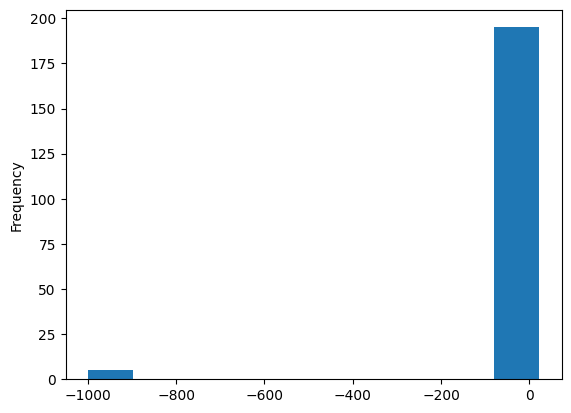

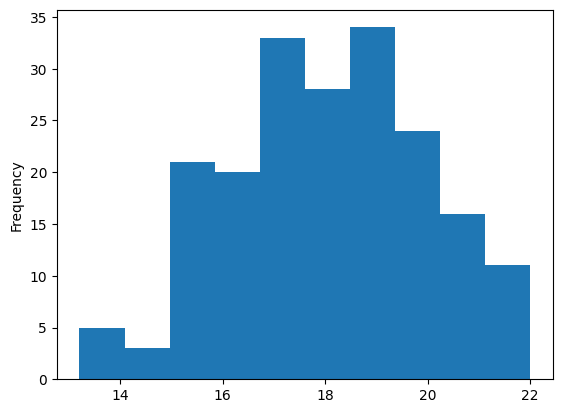

18.02922409415129
18.02922409415129


In [21]:
# Your solution here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Données de départ : 200 températures, dont les 5 premières sont
# des valeurs invalides (capteur bloqué à -999)
rng = np.random.default_rng(0)
temp_celsius = pd.Series(rng.normal(18.0, 2.0, 200))
temp_celsius[:5] = -999.0

# --- Partie 1 : histogramme des valeurs brutes ---
# Objectif : tracer la distribution sans rien nettoyer, pour voir
# l'effet des valeurs invalides sur le graphique
temp_celsius.plot(kind="hist")
plt.show()

# --- Partie 2 : histogramme après filtrage ---
# Objectif : ne garder que les valeurs plausibles (> -50 °C), puis retracer.
# Étape a : construire le masque
mask = temp_celsius > -50
# Étape b : filtrer la Series avec le masque
filtered = temp_celsius[mask]
# Étape c : tracer l'histogramme du résultat
filtered.plot(kind="hist")
plt.show()
# Commentaire à écrire : lequel des deux graphiques tu croirais, et pourquoi ?

# second one because more precise

# --- Partie 3 : marquer les valeurs invalides comme manquantes ---
# Objectif : remplacer les valeurs < -50 par NaN directement dans temp_celsius,
# avec une assignation masquée via .loc
temp_celsius.loc[temp_celsius < -50] = np.nan # loc et non ffill car loc n'utilise pas de parenthèses

# Objectif : comparer la moyenne obtenue ici avec celle de la Series filtrée
print(temp_celsius.mean())
print(filtered.mean())
# Commentaire à écrire : pourquoi les deux moyennes sont-elles identiques ?
# identiques car on filtre les valeurs negligeable car peu nombreuses